# Data Preprocessing

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns

Link to dataset: https://www.kaggle.com/datasets/bhargavchirumamilla/thyroid-cancer-risk-dataset/data

In [17]:
thyroidC = pd.read_csv('./Data/thyroid_cancer_risk_data.csv')
thyroidC.head()

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


In [18]:
#Look for outliers in numerical variables
thyroidC.describe()

,Patient_ID,Age,TSH_Level,T3_Level,T4_Level,Nodule_Size
count,212691.00000,212691.000000,212691.000000,212691.000000,212691.000000,212691.000000
mean,106346.00000,51.918497,5.045102,2.001727,8.246204,2.503403
std,61398.74739,21.632815,2.860264,0.866248,2.164188,1.444631
min,1.00000,15.000000,0.100000,0.500000,4.500000,0.000000
25%,53173.50000,33.000000,2.570000,1.250000,6.370000,1.250000
50%,106346.00000,52.000000,5.040000,2.000000,8.240000,2.510000
75%,159518.50000,71.000000,7.520000,2.750000,10.120000,3.760000
max,212691.00000,89.000000,10.000000,3.500000,12.000000,5.000000


<Axes: >

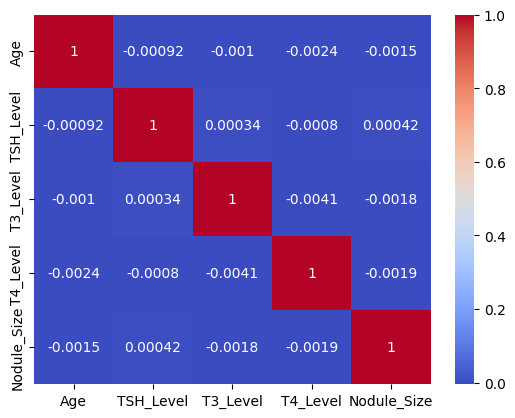

In [19]:
corr = thyroidC[['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

<Axes: xlabel='T4_Level', ylabel='Count'>

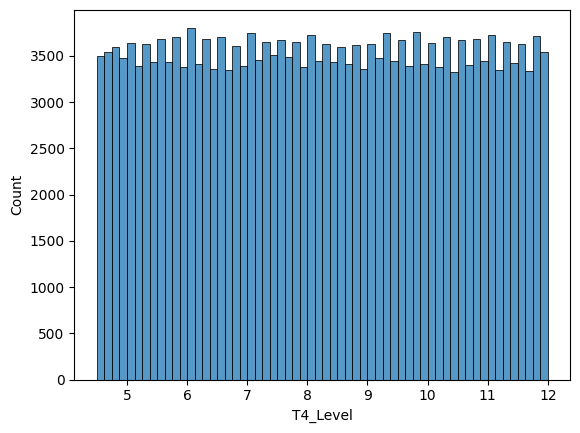

In [20]:
sns.histplot(data=thyroidC, x='T4_Level')

Data is definitely meant to be used in a for classification than linear regression. Also did some digging on Kaggle because the first data set I tried to use ended up being fabricated and was giving extremely weird and bad performance in my regression models.

In [21]:
#Drop patient ID because it has no valuable meaning for prediciton
thyroidC.drop(columns = ['Patient_ID'], inplace=True)

#Drop any columns that have Null values as well as this could negatively impact prediction
thyroidC.dropna(inplace=True)
thyroidC.head()

,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


The next thing to do is splitting up the categorical variables using one hot encoding/label encoding to separate them in a numerical way.

In [22]:
from sklearn.preprocessing import OneHotEncoder
#Country not included because too many countries to use onehotencoder, also likely not relevant to prediction
categorical_columns = ['Gender', 'Ethnicity'] 

# Initialize the OneHotEncoder
encoder = OneHotEncoder(drop=None)

# Fit and transform the categorical columns
encoded_data = encoder.fit_transform(thyroidC[categorical_columns])

# Convert the encoded data into a DataFrame
encoded_df = pd.DataFrame(encoded_data.toarray(), columns=encoder.get_feature_names_out(categorical_columns))

# Drop the original categorical columns and concatenate the encoded ones
thyroid_encoded = pd.concat([thyroidC, encoded_df], axis=1)

# Display the encoded DataFrame
thyroid_encoded.head()

,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,...,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis,Gender_Female,Gender_Male,Ethnicity_African,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Hispanic,Ethnicity_Middle Eastern
0,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,...,1.08,Low,Benign,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,...,4.05,Low,Benign,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,...,4.61,Low,Benign,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,75,Female,India,Asian,No,No,No,No,No,No,...,2.46,Medium,Benign,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4,35,Female,Germany,African,Yes,Yes,No,No,No,No,...,2.11,High,Benign,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [30]:
#help(OneHotEncoder)

In [30]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
#This line ensures that the label encoding assigns higher labels with higher risk
thyroid_encoded['Thyroid_Cancer_Risk'] = pd.Categorical(thyroid_encoded['Thyroid_Cancer_Risk'], categories=['Low', 'Medium', 'High'], ordered=True)

thyroid_encoded['Thyroid_Cancer_Risk Encoded'] = label_encoder.fit_transform(thyroid_encoded['Thyroid_Cancer_Risk'])
print(label_encoder.classes_)

thyroid_encoded['Diagnosis Encoded'] = label_encoder.fit_transform(thyroid_encoded['Diagnosis'])
print(label_encoder.classes_)

#Also want to label encode the yes/no columns
for col in thyroid_encoded[['Family_History', 'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes']].columns:
    thyroid_encoded[col] = label_encoder.fit_transform(thyroid_encoded[col])
thyroid_encoded.columns

['High' 'Low' 'Medium']
['Benign' 'Malignant']


Index(['Age', 'Gender', 'Country', 'Ethnicity', 'Family_History',
       'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity',
       'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size',
       'Thyroid_Cancer_Risk', 'Diagnosis', 'Gender_Female', 'Gender_Male',
       'Ethnicity_African', 'Ethnicity_Asian', 'Ethnicity_Caucasian',
       'Ethnicity_Hispanic', 'Ethnicity_Middle Eastern',
       'Thyroid_Cancer_Risk Encoded', 'Diagnosis Encoded'],
      dtype='object')

In [31]:
thyroid_encoded[['Thyroid_Cancer_Risk', 'Thyroid_Cancer_Risk Encoded']]

,Thyroid_Cancer_Risk,Thyroid_Cancer_Risk Encoded
0,Low,1
1,Low,1
2,Low,1
3,Medium,2
4,High,0
...,...,...
212686,Low,1
212687,Medium,2
212688,Medium,2
212689,Medium,2


The label encoder is incorrectly ordering the risk factor using label encoding so I am going to do it by hand. It shouldn't make a difference in prediction but just in case and as best practice I am going to make sure they are ordered correctly.

In [34]:
# Define the mapping
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

# Apply the mapping
thyroid_encoded['Thyroid_Cancer_Risk Encoded'] = thyroid_encoded['Thyroid_Cancer_Risk'].map(risk_mapping)
thyroid_encoded.head()

,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,...,Diagnosis,Gender_Female,Gender_Male,Ethnicity_African,Ethnicity_Asian,Ethnicity_Caucasian,Ethnicity_Hispanic,Ethnicity_Middle Eastern,Thyroid_Cancer_Risk Encoded,Diagnosis Encoded
0,66,Male,Russia,Caucasian,0,1,0,0,0,0,...,Benign,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0
1,29,Male,Germany,Hispanic,0,1,0,0,0,0,...,Benign,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,0
2,86,Male,Nigeria,Caucasian,0,0,0,0,0,0,...,Benign,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0
3,75,Female,India,Asian,0,0,0,0,0,0,...,Benign,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0
4,35,Female,Germany,African,1,1,0,0,0,0,...,Benign,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2,0


In [35]:
thyroid_encoded[['Thyroid_Cancer_Risk', 'Thyroid_Cancer_Risk Encoded']]

,Thyroid_Cancer_Risk,Thyroid_Cancer_Risk Encoded
0,Low,0
1,Low,0
2,Low,0
3,Medium,1
4,High,2
...,...,...
212686,Low,0
212687,Medium,1
212688,Medium,1
212689,Medium,1


As we can see it is now correctly label encoded to match the severity of the risk factor

Now that my data is properly cleaned and reshaped to be used for the various models I will write it to a new csv file. I am aware that the project says to split into train validation and test sets in this notebook but that seems cumbersome to process to the other file so instead I will just do that at the beginning of my proj3_machine_learning file. I also decided to leave in the original categorical columns even though they will not be used in my algorithms because they help provide clarity when reading through the data instead of looking at encoded columns

In [36]:
thyroid_encoded.to_csv('./Data/Cleaned_thyroidcancer_data.csv', index=False)